# Face Recognition Attendance System — YuNet + SFace

This notebook builds on the original face-recognition notebook and provides:

- Dataset loading from Google Drive
- YuNet face detection
- SFace face embeddings
- Face alignment
- Embedding database
- Train/test evaluation
- Threshold search
- Unknown-person rejection
- Recognition testing
- Export of the database for a local webcam application

**Important:** The live webcam section is provided separately because normal `cv2.VideoCapture(0)` does not directly access the user's webcam from a hosted Colab runtime.


In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [5]:
dataset_path = Path('D:/Dataset')

print("Dataset exists:", dataset_path.exists())

if dataset_path.exists():
    print("\nPeople:")
    for folder in dataset_path.iterdir():
        if folder.is_dir():
            print(" -", folder.name)


Dataset exists: True

People:
 - 3wd
 - Elmenoufy
 - Elsayed
 - Mohamed
 - Sasa


## 1. Load the dataset

Expected structure:

```text
Dataset/
├── Mohamed/
├── Elsayed/
├── Sasa/
├── 3wd/
└── Elmenoufy/
```

Try to collect around **20–30 useful images per person** before judging the final recognition performance.


In [ ]:
# Collect image paths and labels

image_paths = []
labels = []

valid_extensions = {".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"}

for person_folder in sorted(dataset_path.iterdir()):

    if not person_folder.is_dir():
        continue

    person_name = person_folder.name

    for image_path in sorted(person_folder.iterdir()):

        if image_path.suffix in valid_extensions:
            image_paths.append(image_path)
            labels.append(person_name)

df = pd.DataFrame({
    "path": image_paths,
    "name": labels
})

print("Total images:", len(df))
print("\nImages per person:")
print(df["name"].value_counts())


Total images: 27

Images per person:
name
3wd          6
Sasa         6
Elmenoufy    5
Elsayed      5
Mohamed      5
Name: count, dtype: int64


In [ ]:
# Download YuNet and SFace

!wget -q -O face_detection_yunet_2023mar.onnx \
https://github.com/opencv/opencv_zoo/raw/main/models/face_detection_yunet/face_detection_yunet_2023mar.onnx

!wget -q -O face_recognition_sface_2021dec.onnx \
https://github.com/opencv/opencv_zoo/raw/main/models/face_recognition_sface/face_recognition_sface_2021dec.onnx

print("YuNet:", os.path.getsize("face_detection_yunet_2023mar.onnx"), "bytes")
print("SFace:", os.path.getsize("face_recognition_sface_2021dec.onnx"), "bytes")


YuNet: 232589 bytes
SFace: 38696353 bytes


## 2. Initialize YuNet and SFace


In [ ]:
# YuNet face detector

detector = cv2.FaceDetectorYN_create(
    "face_detection_yunet_2023mar.onnx",
    "",
    (320, 320),
    score_threshold=0.60,
    nms_threshold=0.30,
    top_k=5000
)

# SFace recognizer
rec = cv2.FaceRecognizerSF_create(
    "face_recognition_sface_2021dec.onnx",
    ""
)

print("Models loaded successfully.")


Models loaded successfully.


## 3. Face detection + SFace embedding

The function below:

1. Reads the image
2. Detects faces using YuNet
3. Selects the largest face
4. Aligns the face using SFace
5. Generates a 128-dimensional embedding
6. L2-normalizes the embedding


In [ ]:
def get_embedding(image_path, return_face=False):

    img = cv2.imread(str(image_path))

    if img is None:
        return None

    h, w = img.shape[:2]

    detector.setInputSize((w, h))

    _, faces = detector.detect(img)

    if faces is None or len(faces) == 0:
        return None

    # Select largest face
    face = max(
        faces,
        key=lambda f: f[2] * f[3]
    )

    # Align face
    aligned = rec.alignCrop(img, face)

    # Generate SFace embedding
    embedding = rec.feature(aligned)

    embedding = embedding.flatten()

    # Normalize
    norm = np.linalg.norm(embedding)

    if norm == 0:
        return None

    embedding = embedding / norm

    if return_face:
        return embedding, img, face, aligned

    return embedding


## 4. Check YuNet detection visually

This helps identify the images responsible for the detection problem.


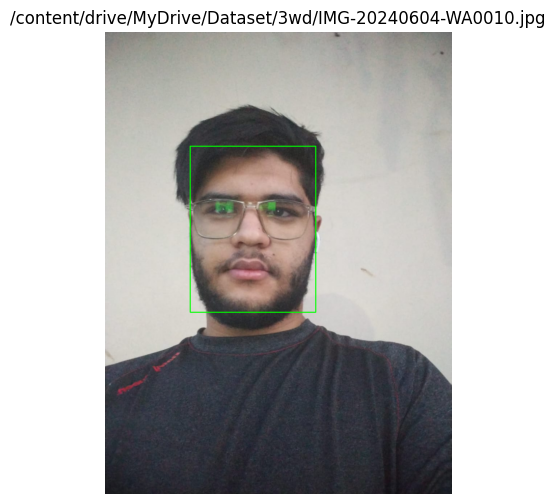

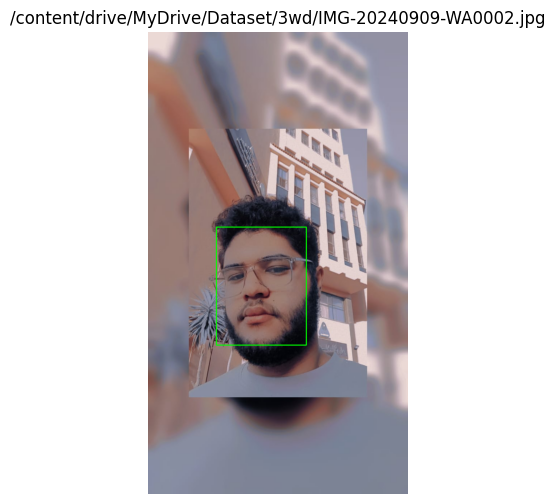

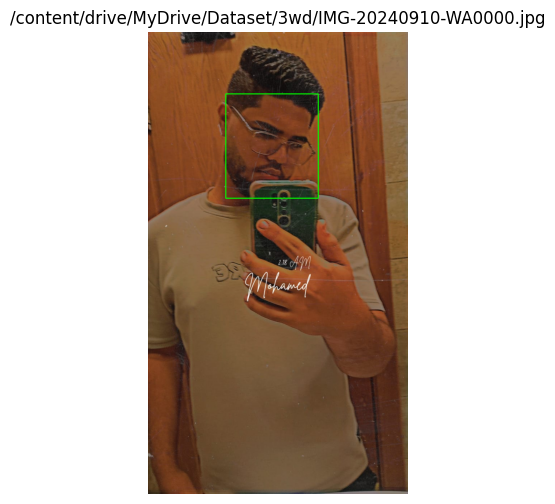

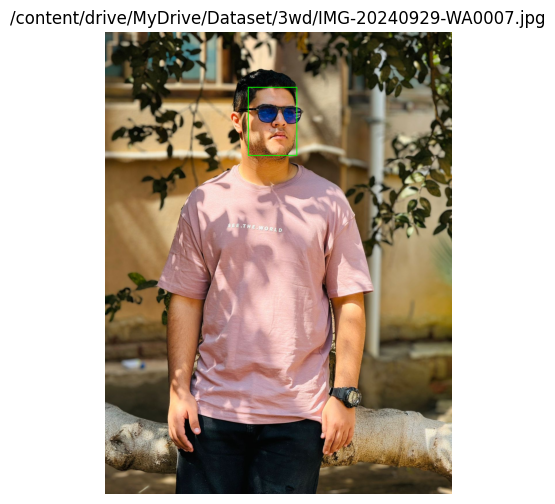

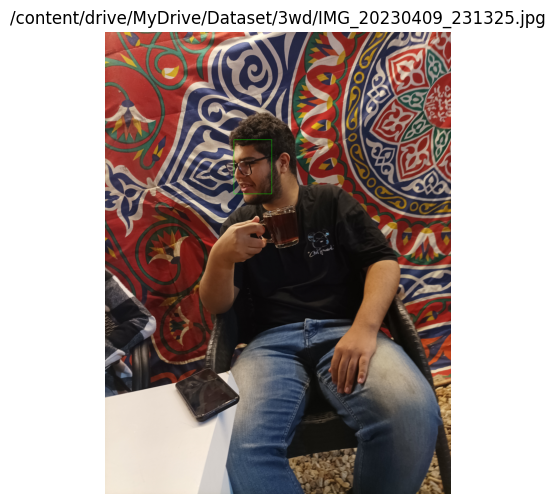

In [ ]:
def show_detection(image_path):

    img = cv2.imread(str(image_path))

    if img is None:
        print("Could not read:", image_path)
        return

    display_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w = img.shape[:2]
    detector.setInputSize((w, h))

    _, faces = detector.detect(img)

    if faces is not None:

        for face in faces:

            x, y, fw, fh = face[:4].astype(int)

            cv2.rectangle(
                display_img,
                (x, y),
                (x + fw, y + fh),
                (0, 255, 0),
                2
            )

    plt.figure(figsize=(8, 6))
    plt.imshow(display_img)
    plt.axis("off")
    plt.title(str(image_path))
    plt.show()


# Show a few images
for path in image_paths[:5]:
    show_detection(path)


## 5. Generate all face embeddings


In [ ]:
embeddings = []
embedding_labels = []
successful_paths = []
failed_images = []

for path, name in zip(image_paths, labels):

    embedding = get_embedding(path)

    if embedding is None:
        failed_images.append(path)
        continue

    embeddings.append(embedding)
    embedding_labels.append(name)
    successful_paths.append(path)

embeddings = np.array(embeddings, dtype=np.float32)
embedding_labels = np.array(embedding_labels)

print("Embedding shape:", embeddings.shape)
print("Successful images:", len(embeddings))
print("Failed images:", len(failed_images))


Embedding shape: (24, 128)
Successful images: 24
Failed images: 3


In [ ]:
# Display failed images

if failed_images:

    print("Images where YuNet did not find a face:\n")

    for path in failed_images:
        print(path)

else:
    print("No failed images.")


Images where YuNet did not find a face:

/content/drive/MyDrive/Dataset/Elsayed/IMG_20240824_140519.jpg
/content/drive/MyDrive/Dataset/Mohamed/IMG_20240920_214011.jpg
/content/drive/MyDrive/Dataset/Mohamed/IMG_20260826_164221.jpg


## 6. Train/test split

We split the **images/embeddings**, rather than comparing every image against itself.

This gives a more meaningful estimate of recognition performance.


In [ ]:
# Check that every person has enough images

counts = pd.Series(embedding_labels).value_counts()

print(counts)

if counts.min() < 2:
    raise ValueError(
        "At least 2 successfully detected images are required per person."
    )


3wd          6
Sasa         6
Elmenoufy    5
Elsayed      4
Mohamed      3
Name: count, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    embeddings,
    embedding_labels,
    test_size=0.25,
    random_state=42,
    stratify=embedding_labels
)

print("Training images:", len(X_train))
print("Testing images:", len(X_test))
print("\nTraining distribution:")
print(pd.Series(y_train).value_counts())


Training images: 18
Testing images: 6

Training distribution:
Sasa         5
Elmenoufy    4
3wd          4
Elsayed      3
Mohamed      2
Name: count, dtype: int64


## 7. Build the face database

Each person can have multiple reference embeddings.


In [ ]:
face_database = {}

for embedding, name in zip(X_train, y_train):

    if name not in face_database:
        face_database[name] = []

    face_database[name].append(embedding)

for name in face_database:
    face_database[name] = np.array(
        face_database[name],
        dtype=np.float32
    )

    print(
        f"{name}: {face_database[name].shape}"
    )


Sasa: (5, 128)
Elmenoufy: (4, 128)
3wd: (4, 128)
Elsayed: (3, 128)
Mohamed: (2, 128)


## 8. Recognition function

Because all embeddings are normalized, the dot product is cosine similarity.


In [ ]:
def recognize_embedding(
    embedding,
    database,
    threshold=0.45
):

    best_name = "Unknown"
    best_score = -1.0

    for name, person_embeddings in database.items():

        scores = person_embeddings @ embedding

        score = float(np.max(scores))

        if score > best_score:
            best_score = score
            best_name = name

    if best_score < threshold:
        best_name = "Unknown"

    return best_name, best_score


## 9. Evaluate recognition

For the known-person test set, the threshold is initially set low enough that we can see the raw recognition behavior.

The next section searches for a better threshold.


In [ ]:
test_predictions = []
test_scores = []

for embedding in X_test:

    name, score = recognize_embedding(
        embedding,
        face_database,
        threshold=0.0
    )

    test_predictions.append(name)
    test_scores.append(score)

print(
    classification_report(
        y_test,
        test_predictions,
        zero_division=0
    )
)

print(
    "Known-person accuracy:",
    accuracy_score(y_test, test_predictions)
)


              precision    recall  f1-score   support

         3wd       1.00      1.00      1.00         2
   Elmenoufy       1.00      1.00      1.00         1
     Elsayed       1.00      1.00      1.00         1
     Mohamed       1.00      1.00      1.00         1
        Sasa       1.00      1.00      1.00         1

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6

Known-person accuracy: 1.0


## 10. Search for a useful recognition threshold

This searches thresholds using the held-out test set.

**Note:** With a very small dataset, this number can be unstable. A larger dataset gives a much more trustworthy threshold.


In [ ]:
thresholds = np.arange(0.20, 0.81, 0.01)

threshold_results = []

for threshold in thresholds:

    predictions = []

    for embedding in X_test:

        name, score = recognize_embedding(
            embedding,
            face_database,
            threshold=threshold
        )

        predictions.append(name)

    accuracy = np.mean(
        np.array(predictions) == y_test
    )

    threshold_results.append(
        [threshold, accuracy]
    )

threshold_results = np.array(threshold_results)

best_index = np.argmax(threshold_results[:, 1])

best_threshold = float(
    threshold_results[best_index, 0]
)

best_accuracy = float(
    threshold_results[best_index, 1]
)

print("Best threshold:", round(best_threshold, 3))
print("Best test accuracy:", round(best_accuracy, 4))


Best threshold: 0.2
Best test accuracy: 1.0


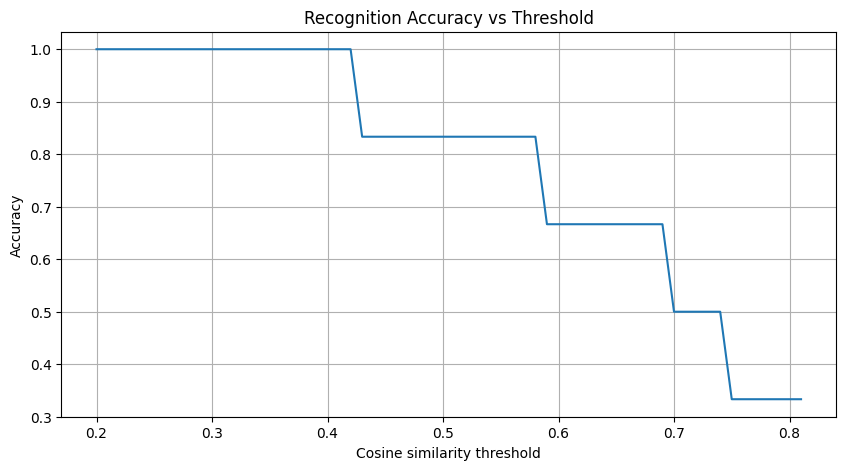

In [ ]:
# Plot threshold performance

plt.figure(figsize=(10, 5))

plt.plot(
    threshold_results[:, 0],
    threshold_results[:, 1]
)

plt.xlabel("Cosine similarity threshold")
plt.ylabel("Accuracy")
plt.title("Recognition Accuracy vs Threshold")
plt.grid()
plt.show()


## 11. Evaluate using the selected threshold


In [ ]:
final_predictions = []
final_scores = []

for embedding in X_test:

    name, score = recognize_embedding(
        embedding,
        face_database,
        threshold=best_threshold
    )

    final_predictions.append(name)
    final_scores.append(score)

print(
    classification_report(
        y_test,
        final_predictions,
        zero_division=0
    )
)

print(
    "Final accuracy:",
    accuracy_score(y_test, final_predictions)
)


              precision    recall  f1-score   support

         3wd       1.00      1.00      1.00         2
   Elmenoufy       1.00      1.00      1.00         1
     Elsayed       1.00      1.00      1.00         1
     Mohamed       1.00      1.00      1.00         1
        Sasa       1.00      1.00      1.00         1

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6

Final accuracy: 1.0


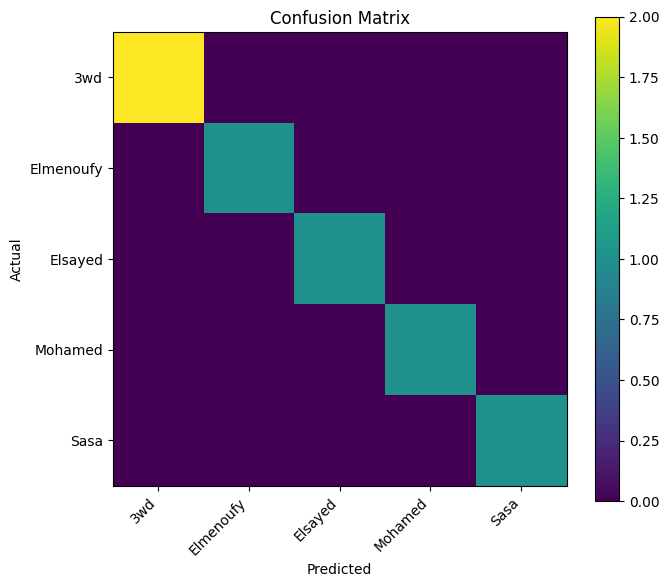

In [ ]:
# Confusion matrix for the known identities

cm_labels = sorted(np.unique(y_test))

cm = confusion_matrix(
    y_test,
    final_predictions,
    labels=cm_labels
)

plt.figure(figsize=(7, 6))

plt.imshow(cm)

plt.xticks(
    range(len(cm_labels)),
    cm_labels,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(cm_labels)),
    cm_labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.colorbar()
plt.tight_layout()
plt.show()


## 12. Test individual images


In [ ]:
def recognize_image(image_path):

    result = get_embedding(image_path, return_face=True)

    if result is None:
        print("No face detected:", image_path)
        return

    embedding, img, face, aligned = result

    name, score = recognize_embedding(
        embedding,
        face_database,
        threshold=best_threshold
    )

    print("Image:", image_path)
    print("Prediction:", name)
    print("Similarity:", round(score, 4))

    display_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    x, y, w, h = face[:4].astype(int)

    cv2.rectangle(
        display_img,
        (x, y),
        (x + w, y + h),
        (0, 255, 0),
        2
    )

    cv2.putText(
        display_img,
        f"{name} {score:.2f}",
        (x, max(25, y - 10)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 255, 0),
        2
    )

    plt.figure(figsize=(8, 6))
    plt.imshow(display_img)
    plt.axis("off")
    plt.show()


Image: /content/drive/MyDrive/Dataset/Elmenoufy/IMG_2617.JPG
Prediction: Elmenoufy
Similarity: 1.0


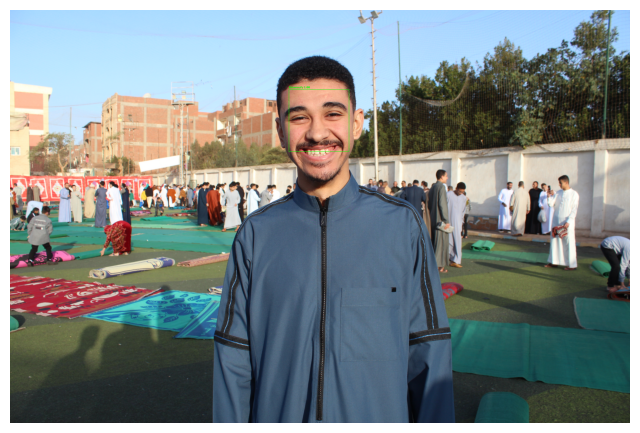

In [ ]:
# Example
# Change this to any image in your dataset

if len(successful_paths) > 0:
    recognize_image(successful_paths[8])


## 13. Save the face database

The files produced here can be used by a local Python webcam program.


In [ ]:
np.save(
    "face_database.npy",
    face_database,
    allow_pickle=True
)

np.save(
    "best_threshold.npy",
    np.array(best_threshold)
)

print("Saved:")
print(" - face_database.npy")
print(" - best_threshold.npy")


Saved:
 - face_database.npy
 - best_threshold.npy


In [ ]:
# Download database files

from google.colab import files

files.download("face_database.npy")
files.download("best_threshold.npy")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 14. Optional: Generate a local webcam script

The following cell creates a `.py` file that you can run on your own computer.

Put these files in the same folder:

```text
face_recognition_live.py
face_database.npy
best_threshold.npy
face_detection_yunet_2023mar.onnx
face_recognition_sface_2021dec.onnx
```

Then run:

```bash
python face_recognition_live.py
```

Press **Q** to quit.


In [ ]:
live_code = r'''
import cv2
import numpy as np


# =========================
# Load database
# =========================

face_database = np.load(
    "face_database.npy",
    allow_pickle=True
).item()

threshold = float(
    np.load("best_threshold.npy")
)


# =========================
# Load models
# =========================

detector = cv2.FaceDetectorYN_create(
    "face_detection_yunet_2023mar.onnx",
    "",
    (320, 320),
    score_threshold=0.60,
    nms_threshold=0.30,
    top_k=5000
)

rec = cv2.FaceRecognizerSF_create(
    "face_recognition_sface_2021dec.onnx",
    ""
)


# =========================
# Recognition
# =========================

def recognize_embedding(
    embedding,
    database,
    threshold
):

    best_name = "Unknown"
    best_score = -1.0

    for name, person_embeddings in database.items():

        scores = person_embeddings @ embedding

        score = float(np.max(scores))

        if score > best_score:
            best_score = score
            best_name = name

    if best_score < threshold:
        best_name = "Unknown"

    return best_name, best_score


# =========================
# Camera
# =========================

cap = cv2.VideoCapture(0)

if not cap.isOpened():
    raise RuntimeError("Could not open webcam.")


while True:

    ret, frame = cap.read()

    if not ret:
        break

    # Mirror camera
    frame = cv2.flip(frame, 1)

    h, w = frame.shape[:2]

    detector.setInputSize((w, h))

    _, faces = detector.detect(frame)

    if faces is not None:

        for face in faces:

            x, y, fw, fh = face[:4].astype(int)

            # Align
            aligned = rec.alignCrop(
                frame,
                face
            )

            # SFace embedding
            embedding = rec.feature(
                aligned
            ).flatten()

            norm = np.linalg.norm(embedding)

            if norm == 0:
                continue

            embedding = embedding / norm

            # Recognize
            name, score = recognize_embedding(
                embedding,
                face_database,
                threshold
            )

            # Draw face box
            cv2.rectangle(
                frame,
                (x, y),
                (x + fw, y + fh),
                (0, 255, 0),
                2
            )

            # Draw label
            label = f"{name} | {score:.2f}"

            cv2.putText(
                frame,
                label,
                (x, max(25, y - 10)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                (0, 255, 0),
                2
            )

    cv2.imshow(
        "Face Recognition",
        frame
    )

    # Q = quit
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break


cap.release()
cv2.destroyAllWindows()
'''

with open("face_recognition_live.py", "w") as f:
    f.write(live_code)

print("Created face_recognition_live.py")


Created face_recognition_live.py


# Recommended next step

Before trusting the accuracy number, increase the dataset to approximately **20–30 good images per person**.

Then rerun the notebook from the embedding section onward.

For the final attendance system, the next upgrade should be:

**Webcam → YuNet → SFace → temporal smoothing → identity confirmation → attendance database → timestamp**

This notebook intentionally keeps recognition separate from attendance so that we can verify recognition quality first.
